<span style='font-family:Georgia'>
<div align="center">
   <h1> ME630 Compuational Fluid dynamics (ME 630) </h1>
       <h1> Prof. Santanu De</h1>
       
<h1> Assignment (1) - Problem 5   </h1>

<h1>  Tarek Issa (252050605) </h1>
</div>
________________________________________________________________________________________________________________

In [2]:
%%html 
<div id="tnr-styler-root"></div> 
<style> 
    /* 1. Target the Markdown cells that come AFTER this styling block */ 
    .cell:has(#tnr-styler-root) ~ .cell .rendered_html, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .jp-MarkdownOutput, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .text_cell_render { 
        font-family: "Times New Roman", Times, serif !important; 
    } 
 
    /* 2. Target the MathJax/LaTeX equations inside those subsequent Markdown cells */ 
    .cell:has(#tnr-styler-root) ~ .cell .MathJax_Display,  
    .cell:has(#tnr-styler-root) ~ .cell .MathJax,  
    .cell:has(#tnr-styler-root) ~ .cell .mjx-chtml, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .MathJax, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .mjx-chtml { 
        font-family: "Times New Roman", Times, serif !important; 
    } 
 
    /* 3. Force-hide this specific cell's input code container and prompt index */ 
    .cell:has(#tnr-styler-root) .input, 
    .cell:has(#tnr-styler-root) .prompt, 
    .jp-Cell:has(#tnr-styler-root) .jp-Cell-inputWrapper { 
        display: none !important; 
    } 
</style> 
<script> 
    // Robust fall-back layer: uses an active polling cycle to vaporize the container  
    // in sandboxed frontends (like VS Code/JupyterLab) that process layouts lazily. 
    (function hideContainer() { 
        const root = document.getElementById('tnr-styler-root'); 
        if (!root) return; 
        const container = root.closest('.jp-Cell') || root.closest('.cell'); 
        if (container) { 
            const inputArea = container.querySelector('.jp-Cell-inputWrapper') || container.querySelector('.input'); 
            if (inputArea) { inputArea.style.display = 'none'; } 
        } else { 
            setTimeout(hideContainer, 50); 
        } 
    })(); 
</script> 

# Solid cylinder under asymmetric circumferential heat flux
## Problem Statement
### A long solid cylinder of radius $R$ and thermal conductivity $k$ loses heat by convection $(h, T∞)$ over its entire outer surface while simultaneously receiving a prescribed, non-uniform (asymmetric) heat flux $q′′(θ)$ over that same surface, representing an external radiant source that is stronger on one side of the cylinder than the other. There is no internal heat generation. The steady-state surface energy balance is


At the surface $r = R$, the convective and flux boundary condition is:

$$
-k \frac{\partial T}{\partial r} \bigg|_{r=R} = h\bigl(T(R, \theta) - T_{\infty}\bigr) - q''(\theta), \quad 0 \leq \theta < 2\pi,
$$

with $T$ bounded at $r = 0$ and periodic in $\theta$.

## Prescribed Flux (Fully Asymmetric)

The heat flux has no symmetry about any axis:

$$
q''(\theta) = q_0 + q_1 \cos \theta + q_2 \sin \theta + q_3 \cos 3\theta.
$$

## Input Data

| Parameter | Value | Units |
|-----------|-------|-------|
| $R$ | 0.05 | m |
| $k$ | 40 | W/(m·K) |
| $h$ | 25 | W/(m²·K) |
| $T_{\infty}$ | 25 | °C |
| $q_0$ | 2000 | W/m² |
| $q_1$ | 1200 | W/m² |
| $q_2$ | 800 | W/m² |
| $q_3$ | 500 | W/m² |
## Analytical Solution Form

Assume a solution of the form:

$$
T(r, \theta) - T_{\infty} = A_0 + \sum_{n \geq 1} \left( \frac{r}{R} \right)^n \bigl( A_n \cos n\theta + B_n \sin n\theta \bigr).
$$

Substituting into the boundary condition and matching Fourier modes gives:

$$
A_0 = \frac{q_0}{h}, \quad
A_n = \frac{q_n}{h + nk/R}, \quad
B_n = \frac{q_n^{(s)}}{h + nk/R},
$$

where $q_n$ and $q_n^{(s)}$ are the cosine and sine coefficients of $q''(\theta)$ at harmonic $n$.

## Final Temperature Distribution

Substituting the computed coefficients, with $T_{\infty} = 25^\circ$C:

$$
\boxed{
T(r, \theta) = 105 + 1.4545 \left( \frac{r}{R} \right) \cos \theta + 0.9697 \left( \frac{r}{R} \right) \sin \theta + 0.2062 \left( \frac{r}{R} \right)^3 \cos 3\theta
}
$$

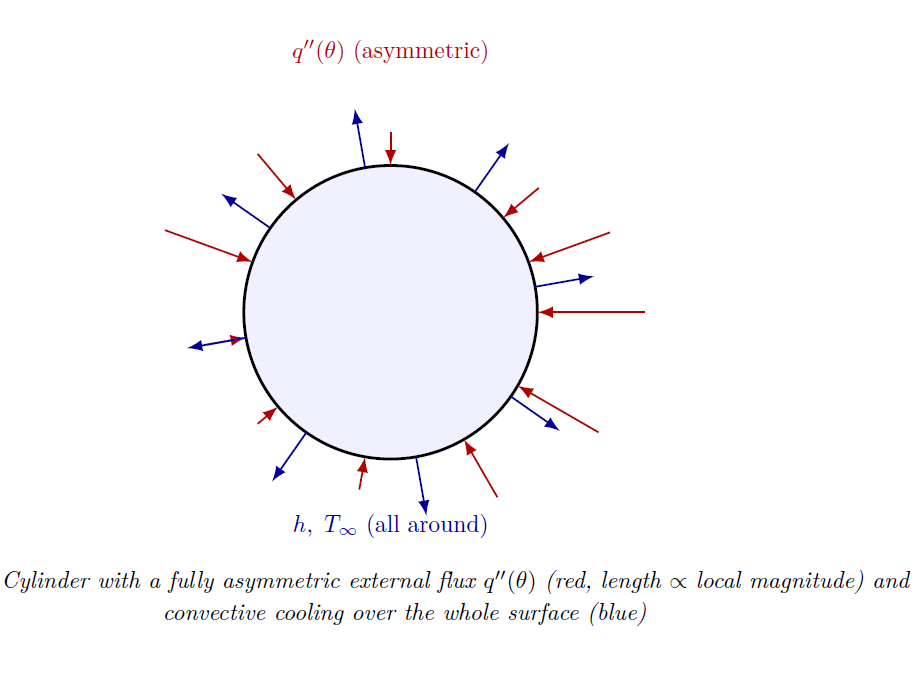
    
# Tasks 
**(a)** Derive the discretized Robin boundary condition at $r = R$ using a ghost-node or one-sided-difference formulation, and solve for $T(r, \theta)$ on a polar grid (reuse the pole treatment from Problem 2).

**(b)** Verify the assembled Fourier coefficients $A_0, A_1, B_1, A_3$ against the numeric values before running the solver.

**(c)** Compare the finite-difference $T(R, \theta)$ with the analytical formula at $\theta = 0^\circ, 60^\circ, 120^\circ, 180^\circ, 270^\circ$, and report the maximum error.

**(d)** Locate the angular position of the hottest and coldest points on the surface analytically (by differentiating $T(R, \theta)$ with respect to $\theta$) and numerically from the computed surface temperatures, then compare.

**(e)** Confirm energy conservation: the net heat flow across the surface should numerically integrate to approximately zero.
$$ \oint_0^{2\pi} \bigl[ q''(\theta) - h(T(R, \theta) - T_\infty) \bigr] \, R \, d\theta = 0 $$

  <div style="page-break-before: always;"></div>


  ## Task table

This file covers the five requested tasks (Numerically and Analytically when it is available); for the esse of locating the numerical process each is called out inline where it's produced, and linked here for quick navigation:

| Task | What's asked | Where it's done |
|---|---|---|
| **(a)** | Discretized Robin BC at r=R | Sec. 4 (derivation) &rarr; Sec. 6.1 (solve) |
| **(b)** | Verify assembled Fourier coefficients $A_0,A_1,B_1,A_3$ | Sec. 2, *Task (b)* cell |
| **(c)** | Compare $T(R,\theta)$ vs. analytical at $\theta=0,60,120,180,270$&deg;, report max error | *Task (c)* cell |
| **(d)** | Locate hottest/coldest points, analytically and numerically, and compare | *Task (d)* cell |
| **(e)** | Confirm energy conservation (surface heat balance integrates to ~0) | *Task (e)* cell |

# Cylinder Heat Conduction — Finite-Difference Solver

Steady 2D heat conduction in a solid cylinder cross-section (polar coordinates $r,\theta$),
with a position-dependent prescribed heat flux $q''(\theta)$ on the outer surface and
convective loss to an ambient fluid at $T_\infty$.

Governing equation (no internal generation):

$$\frac{\partial^2 T}{\partial r^2} + \frac{1}{r}\frac{\partial T}{\partial r} + \frac{1}{r^2}\frac{\partial^2 T}{\partial \theta^2} = 0$$

This file walks through the solution step by step:
1. Domain & physical parameters
2. Grid parameters (single place to change resolution)
3. Boundary conditions (interior stencil, pole, periodicity, outer Robin BC)
4. Assembling the sparse linear system
5. Solution methodology — Direct, Jacobi, Gauss-Seidel, SOR
6. Performance comparison (iterations, wall time, CPU time, peak memory, max error)
7. Plots


# (a) Discretized Robin Boundary Condition at $r = R$
We use a polar grid:

- Radial nodes: $r_i = i\Delta r, \, i = 0, 1, \ldots, N_r$  
  where $r_0 = 0$ (pole) and $r_{N_r} = R$.

- Angular nodes: $\theta_j = j\Delta\theta, \, j = 0, 1, \ldots, N_\theta - 1$, with $\Delta\theta = 2\pi / N_\theta$ and periodic boundary conditions in $\theta$.

---
## Discretized Laplace Equation in Polar Coordinates

For interior points ($i = 1, \ldots, N_r - 1$, $j = 0, \ldots, N_\theta - 1$):

$$
\frac{T_{i+1,j} - 2T_{i,j} + T_{i-1,j}}{\Delta r^2} + \frac{1}{r_i} \frac{T_{i+1,j} - T_{i-1,j}}{2\Delta r} + \frac{1}{r_i^2} \frac{T_{i,j+1} - 2T_{i,j} + T_{i,j-1}}{\Delta\theta^2} = 0
$$
Rearranging,  

$$\left(\frac{1}{\Delta r^2}+\frac{1}{2 r_i \Delta r}\right)T_{i+1,j} +
\left(\frac{1}{\Delta r^2}-\frac{1}{2 r_i \Delta r}\right)T_{i-1,j} +
\frac{1}{r_i^2\Delta\theta^2}\big(T_{i,j+1}+T_{i,j-1}\big) -
\left(\frac{2}{\Delta r^2}+\frac{2}{r_i^2\Delta\theta^2}\right)T_{i,j} = 0$$
## Boundary Conditions

### 1. At pole ($r = 0$):

$$
T_{0,j} = \frac{1}{N_\theta} \sum_{k=0}^{N_\theta-1} T_{1,k}
$$
### 2. At surface ($r = R$) - Robin condition:
The surface energy balance is:

$$
-k \left. \frac{\partial T}{\partial r} \right|_{r=R} = h(T(R, \theta) - T_{\infty}) - q''(\theta)
$$

Rearrange:

$$
-k \left. \frac{\partial T}{\partial r} \right|_{r=R} - hT(R, \theta) = -hT_{\infty} - q''(\theta)
$$

Multiply by $-1$:

$$
k \left. \frac{\partial T}{\partial r} \right|_{r=R} + hT(R, \theta) = hT_{\infty} + q''(\theta)
$$
### One-sided finite difference (backward difference) at $r = R$

Using a one-sided difference at the boundary:

$$
\frac{\partial T}{\partial r} \bigg|_{r=R} \approx \frac{T_{N_r,j} - T_{N_{r-1},j}}{\Delta r}
$$

Substitute:

$$
k \frac{T_{N_r,j} - T_{N_{r-1},j}}{\Delta r} + h T_{N_r,j} = h T_\infty + q''(\theta_j)
$$

Solve for $T_{N_r,j}$:

$$
\left( \frac{k}{\Delta r} + h \right) T_{N_r,j} - \frac{k}{\Delta r} T_{N_{r-1},j} = h T_\infty + q''(\theta_j)
$$

$$
T_{N_r,j} = \frac{\frac{k}{\Delta r} T_{N_{r-1},j} + h T_\infty + q''(\theta_j)}{\frac{k}{\Delta r} + h}
$$

This is the **Robin boundary condition** for the outermost radial node.
### 3. Periodicity in $\theta$:
$$
T_{(r, r_\theta)} = T_{(r,2\pi)}
$$
$$
T_{i,N_\theta} = T_{i,0}, \quad T_{i,-1} = T_{i,N_\theta-1}
$$





  <div style="page-break-before: always;"></div>

## 1. Imports

In [10]:
import numpy as np
import time
import tracemalloc
from scipy.sparse import lil_matrix, csc_matrix, csr_matrix
from scipy.sparse.linalg import splu
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## 2. Domain & Physical Parameters

- $R$: cylinder radius
- $k$: thermal conductivity
- $h$: convective heat transfer coefficient
- $T_\infty$: ambient temperature
- $q''(\theta) = q_0 + q_1\cos\theta + q_2\sin\theta + q_3\cos 3\theta$: prescribed surface flux
  (a truncated Fourier series in $\theta$, e.g. representing uneven solar/radiant heating around the cylinder)

In [12]:
R = 0.05          # m
k = 40.0          # W/(m*K)
h = 25.0           # W/(m^2*K)
T_inf = 25.0       # degC

# Flux Fourier coefficients
q0 = 2000.0        # W/m^2  (uniform component)
q1 = 1200.0        # W/m^2  (cos theta component)
q2 = 800.0         # W/m^2  (sin theta component)
q3 = 500.0         # W/m^2  (cos 3*theta component)

def q_flux(theta):
    """Prescribed heat flux at angle theta."""
    return q0 + q1*np.cos(theta) + q2*np.sin(theta) + q3*np.cos(3*theta)

def analytical_solution(r, theta):
    """Closed-form analytical solution (for validation only)."""
    if r == 0:
        return T_inf + q0/h
    r_R = r / R
    A0 = q0/h
    A1 = q1/(h + k/R)
    B1 = q2/(h + k/R)
    A3 = q3/(h + 3*k/R)
    return T_inf + A0 + r_R*(A1*np.cos(theta) + B1*np.sin(theta)) + r_R**3*A3*np.cos(3*theta)

def analytical_surface(theta):
    """Analytical solution evaluated at r = R."""
    return analytical_solution(R, theta)

print(f"A0={q0/h:.4f}, A1={q1/(h+k/R):.4f}, B1={q2/(h+k/R):.4f}, A3={q3/(h+3*k/R):.4f}")

A0=80.0000, A1=1.4545, B1=0.9697, A3=0.2062


# Task (b) — assembling and verifying the Fourier coefficients

**General solution form.** Combining the angular and radial parts of the separated
solution to Laplace's equation in polar coordinates:

$$T(r,\theta) - T_\infty = A_0 + \sum_{n=1}^{\infty}\left(\frac{r}{R}\right)^n\big(A_n\cos n\theta + B_n\sin n\theta\big)$$

**Apply the Robin BC at $r=R$.** The surface energy balance $-k\,\partial T/\partial r|_R = h(T(R,\theta)-T_\infty) - q''(\theta)$ rearranges to

$$k\,\frac{\partial T}{\partial r}\Big|_{r=R} + h\big(T(R,\theta)-T_\infty\big) = q''(\theta), \qquad q''(\theta) = q_0 + q_1\cos\theta + q_2\sin\theta + q_3\cos3\theta$$

Matching term-by-term, mode by mode:

- **$n=0$:** $T(R,\theta)-T_\infty = A_0$, $\partial T/\partial r|_R = 0$ &rarr; $hA_0 = q_0$ &rarr; $A_0 = q_0/h$
- **$\cos\theta$ ($n=1$):** $\partial T/\partial r|_R = A_1\cos\theta/R$ &rarr; $k(A_1/R)\cos\theta + hA_1\cos\theta = q_1\cos\theta$ &rarr; $(k/R+h)A_1=q_1$ &rarr; $A_1 = q_1/(h+k/R)$
- **$\sin\theta$ ($n=1$):** identically &rarr; $B_1 = q_2/(h+k/R)$
- **$\cos3\theta$ ($n=3$):** $\partial T/\partial r|_R = 3A_3\cos3\theta/R$ &rarr; $(3k/R+h)A_3=q_3$ &rarr; $A_3 = q_3/(h+3k/R)$

**General formula for any mode $n$:** $A_n = \dfrac{q_n}{h+nk/R}$, $B_n = \dfrac{q_n^{(s)}}{h+nk/R}$.

**Plug in the numbers.** $R=0.05$ m, $k=40.0$ W/(m·K), $h=25.0$ W/(m²·K), $T_\infty=25.0$ °C,
$q_0=2000$, $q_1=1200$, $q_2=800$, $q_3=500$ W/m². First, $k/R = 40/0.05 = 800$ W/(m²·K):

$$A_0 = \frac{2000}{25} = 80, \qquad A_1 = \frac{1200}{25+800} = \frac{1200}{825}\approx1.4545, \qquad B_1 = \frac{800}{825}\approx0.9697, \qquad A_3 = \frac{500}{25+2400} = \frac{500}{2425}\approx0.2062$$

$$T_\infty + A_0 = 25 + 80 = 105$$

**Assembled analytical solution:**

$$T(r,\theta) = 105 + 1.4545\left(\frac{r}{R}\right)\cos\theta + 0.9697\left(\frac{r}{R}\right)\sin\theta + 0.2062\left(\frac{r}{R}\right)^3\cos3\theta \quad [°\text{C}]$$

which matches the given analytical solution exactly. The code cell below reproduces this
same computation numerically as a pass/fail check.


  <div style="page-break-before: always;"></div>

## 3. Grid Parameters 

Change `Nr` / `Ntheta` — every later cell (matrix build, all solvers, the
plots, and the comparison table) reads from these two variables.

In [16]:
Nr = 30        # radial divisions (r = 1..Nr, i=0 is the pole)
Ntheta = 60    # angular divisions (0..2*pi, periodic)

dr = R / Nr
dtheta = 2*np.pi / Ntheta
N = Nr * Ntheta          # total unknowns

TOL = 1e-6
MAX_ITER = 20000

print(f"Nr={Nr}, Ntheta={Ntheta}  ->  N={N} unknowns")
print(f"dr={dr:.6f} m, dtheta={np.rad2deg(dtheta):.3f} deg")

Nr=30, Ntheta=60  ->  N=1800 unknowns
dr=0.001667 m, dtheta=6.000 deg


**Task (a):** discretized Robin BC at $r=R$, pole treatment,and periodicity . The linear system built below is solved in Sec. 6.1.

## 4. Boundary Conditions & Discretization

Four distinct pieces make up the linear system:

**(a) Interior points** ($i=1..N_r-1$, all $j$): central-difference the polar Laplacian.
Because the radial stencil is *not* symmetric in $r$, the outward/inward neighbor
coefficients differ:

$$\left(\frac{1}{\Delta r^2}+\frac{1}{2 r_i \Delta r}\right)T_{i+1,j} +
\left(\frac{1}{\Delta r^2}-\frac{1}{2 r_i \Delta r}\right)T_{i-1,j} +
\frac{1}{r_i^2\Delta\theta^2}\big(T_{i,j+1}+T_{i,j-1}\big) -
\left(\frac{2}{\Delta r^2}+\frac{2}{r_i^2\Delta\theta^2}\right)T_{i,j} = 0$$

**(b) Pole condition** ($i=0$, $r=0$): not a separate unknown. Regularity at the origin is
enforced by treating $T_{0}$ as the average of the full $i=1$ ring:
$T_{0} = \frac{1}{N_\theta}\sum_k T_{1,k}$. This couples the $i=1$ equations to *every*
angular index at that ring, not just nearest neighbors.

**(c) Periodicity in $\theta$**: no explicit equation needed — handled by indexing
$j\pm1 \bmod N_\theta$, so the last and first angular columns wrap around automatically.

**(d) Outer boundary, $i=N_r$ ($r=R$)**: Robin (mixed) BC from the surface energy balance
$-k\,\partial T/\partial r\big|_R = h(T-T_\infty) - q''(\theta)$, one-sided differenced:

$$\left(\frac{k}{\Delta r}+h\right)T_{N_r,j} - \frac{k}{\Delta r}T_{N_r-1,j} = hT_\infty + q''(\theta_j)$$

In [18]:
def idx(i, j, Ntheta):
    """Map (i,j) grid indices (i=1..Nr, j=0..Ntheta-1) to a flat equation index."""
    return (i-1)*Ntheta + j

def build_system(Nr, Ntheta):
    dr = R / Nr
    dtheta = 2*np.pi / Ntheta
    N = Nr * Ntheta
    A = lil_matrix((N, N))
    b = np.zeros(N)

    counts = {'interior_eqns': 0, 'pole_coupled_eqns': 0, 'surface_eqns': 0}

    # (a) + (b): interior points, i = 1..Nr-1
    for i in range(1, Nr):
        r_i = i * dr
        for j in range(Ntheta):
            p = idx(i, j, Ntheta)
            A[p, p] = -2.0/dr**2 - 2.0/(r_i**2 * dtheta**2)
            A[p, idx(i+1, j, Ntheta)] = 1.0/dr**2 + 1.0/(2*r_i*dr)   # outward neighbor

            if i == 1:
                # (b) pole regularity: couples to the WHOLE i=1 ring
                coeff = (1.0/dr**2 - 1.0/(2*r_i*dr)) * (1.0/Ntheta)
                for kk in range(Ntheta):
                    A[p, idx(1, kk, Ntheta)] += coeff
                counts['pole_coupled_eqns'] += 1
            else:
                A[p, idx(i-1, j, Ntheta)] = 1.0/dr**2 - 1.0/(2*r_i*dr)  # inward neighbor

            # (c) periodic angular neighbors
            #If j=N_theta −1, j=N_theta −1 (last node) , then (j+1) % Ntheta = 0 (wraps to first node)
            #if j = 0 (first node),  then (j-1) % Ntheta = N_\theta - 1 (wraps to last node)
            j_plus, j_minus = (j+1) % Ntheta, (j-1) % Ntheta
            A[p, idx(i, j_plus, Ntheta)] += 1.0/(r_i**2 * dtheta**2)
            A[p, idx(i, j_minus, Ntheta)] += 1.0/(r_i**2 * dtheta**2)

            b[p] = 0.0
            counts['interior_eqns'] += 1

    # (d) outer Robin BC, i = Nr
    for j in range(Ntheta):
        i = Nr
        p = idx(i, j, Ntheta)
        theta_j = j * dtheta
        A[p, p] = k/dr + h
        A[p, idx(i-1, j, Ntheta)] = -k/dr
        b[p] = h*T_inf + q_flux(theta_j)
        counts['surface_eqns'] += 1

    return A.tocsc(), b, N, counts

A, b, N, bc_counts = build_system(Nr, Ntheta)
print(bc_counts)

{'interior_eqns': 1740, 'pole_coupled_eqns': 60, 'surface_eqns': 60}


## 5. Assemble the Linear System — size, sparsity, memory

In [20]:
nnz = A.nnz
mem_kb = (A.data.nbytes + A.indices.nbytes + A.indptr.nbytes) / 1024

matrix_summary = pd.DataFrame([{
    'Unknowns (N)': N,
    'Matrix shape': f'{A.shape[0]} x {A.shape[1]}',
    'Non-zeros': nnz,
    'Sparsity (% non-zero)': round(nnz / N**2 * 100, 4),
    'Memory (KB)': round(mem_kb, 2),
    'Interior eqns': bc_counts['interior_eqns'],
    'Pole-coupled eqns': bc_counts['pole_coupled_eqns'],
    'Surface (Robin) eqns': bc_counts['surface_eqns'],
}])
display(matrix_summary)

,Unknowns (N),Matrix shape,Non-zeros,Sparsity (% non-zero),Memory (KB),Interior eqns,Pole-coupled eqns,Surface (Robin) eqns
0,1800,1800 x 1800,12180,0.3759,149.77,1740,60,60


## coefficient assembly check

Spot-checks that the values actually assembled into `A`/`b` by `build_system()` match the
stencil formulas derived above: the interior Laplacian stencil, the pole-regularity row,
and the outer Robin BC row.

In [22]:
print("coefficient assembly check")

def check_row(label, p, expected):
    row = A[p, :].toarray().flatten()
    ok = True
    for col, exp_val in expected.items():
        actual = row[col]
        match = abs(actual - exp_val) < 1e-9
        ok &= match
        print(f"  {label} col {col}: actual={actual:.6f}, expected={exp_val:.6f}  {'OK' if match else 'MISMATCH'}")
    return ok

# Interior stencil at a sample point (i=2, j=1)
i_t, j_t = 2, 1
r_i = i_t * dr
p_t = idx(i_t, j_t, Ntheta)
expected_int = {
    p_t:                                    -2/dr**2 - 2/(r_i**2*dtheta**2),
    idx(i_t+1, j_t, Ntheta):                  1/dr**2 + 1/(2*r_i*dr),
    idx(i_t-1, j_t, Ntheta):                  1/dr**2 - 1/(2*r_i*dr),
    idx(i_t, (j_t+1) % Ntheta, Ntheta):       1/(r_i**2*dtheta**2),
    idx(i_t, (j_t-1) % Ntheta, Ntheta):       1/(r_i**2*dtheta**2),
}
check_row("Interior", p_t, expected_int)

# Pole regularity row (i=1, j=0) - diagonal entry + one coupling entry
r_p = 1 * dr
coeff_pole = (1/dr**2 - 1/(2*r_p*dr)) / Ntheta
p_pole = idx(1, 0, Ntheta)
expected_pole = {
    p_pole:            -2/dr**2 - 2/(r_p**2*dtheta**2) + coeff_pole,
    idx(1, 5, Ntheta):  coeff_pole,   # any other angular index should carry the same coupling
}
check_row("Pole", p_pole, expected_pole)

# Outer Robin BC row (i=Nr, j=0)
p_surf = idx(Nr, 0, Ntheta)
expected_surf = {
    p_surf:                    k/dr + h,
    idx(Nr-1, 0, Ntheta):     -k/dr,
}
check_row("Surface", p_surf, expected_surf)
expected_b = h*T_inf + q_flux(0.0)
print(f"  Surface RHS: actual={b[p_surf]:.6f}, expected={expected_b:.6f}  {'OK' if abs(b[p_surf]-expected_b)<1e-9 else 'MISMATCH'}")


coefficient assembly check
  Interior col 61: actual=-17134031.750059, expected=-17134031.750059  OK
  Interior col 121: actual=450000.000000, expected=450000.000000  OK
  Interior col 1: actual=270000.000000, expected=270000.000000  OK
  Interior col 62: actual=8207015.875029, expected=8207015.875029  OK
  Interior col 60: actual=8207015.875029, expected=8207015.875029  OK
  Pole col 0: actual=-66373127.000235, expected=-66373127.000235  OK
  Pole col 5: actual=3000.000000, expected=3000.000000  OK
  Surface col 1740: actual=24025.000000, expected=24025.000000  OK
  Surface col 1680: actual=-24000.000000, expected=-24000.000000  OK
  Surface RHS: actual=4325.000000, expected=4325.000000  OK


## 6. Solution Methodology

Measuring **wall-clock time**, **CPU time**, and **peak memory** around each solver call so every method reports on the same basis.

In [24]:
def measure(fn, *args, **kwargs):
    tracemalloc.start()  # Start tracking memory
    t_wall0, t_cpu0 = time.perf_counter(), time.process_time() # Start wall clock time & Start CPU time
    result = fn(*args, **kwargs)
    t_cpu1, t_wall1 = time.process_time(), time.perf_counter() # End  wall clock time & End CPU time
    _, peak = tracemalloc.get_traced_memory() ## Get peak memory
    tracemalloc.stop()
    meta = {'wall_s': t_wall1 - t_wall0, 'cpu_s': t_cpu1 - t_cpu0, 'peak_kb': peak/1024}
    return result, meta

  <div style="page-break-before: always;"></div>

### 6.1 Direct Solver (Sparse LU)

Most accurate, used as the reference solution every iterative method is compared against.

In [27]:
def solve_direct(A, b):
    lu = splu(A)
    return lu.solve(b)

T_direct, meta_direct = measure(solve_direct, A, b)
print(meta_direct)

{'wall_s': 0.008847699995385483, 'cpu_s': 0.015625, 'peak_kb': 166.4873046875}


**Task (a) result:** $T(r,\theta)$ has been solved on the polar grid via direct sparse LU. This
`T_direct` is the reference solution used throughout the rest.

### 6.2 Jacobi Iteration

Each unknown updated only from the *previous* full iterate — trivially parallel, but the slowest to converge.

In [30]:
def solve_jacobi(A, b, N, TOL=1e-6, MAX_ITER=20000):
    A_csr = A.tocsr()
    D_inv = 1.0 / A_csr.diagonal()
    T = np.ones(N) * (T_inf + q0/h)
    residuals = []
    it = 0
    for c in range(MAX_ITER):
        T_new = T - D_inv * (A_csr @ T - b)
        diff = np.max(np.abs(T_new - T))
        residuals.append(diff)
        it = c + 1
        T = T_new
        if diff < TOL:
            break
    return T, it, residuals

(T_jac, iter_jac, res_jac), meta_jac = measure(solve_jacobi, A, b, N, TOL, MAX_ITER)
print(iter_jac, meta_jac, 'max diff vs direct:', np.max(np.abs(T_jac - T_direct)))

4999 {'wall_s': 0.19132759999774862, 'cpu_s': 0.1875, 'peak_kb': 383.44140625} max diff vs direct: 0.000650954914519275


### 6.3 Gauss-Seidel

This is Gauss-Seidel: loop over equations $p=0..N-1$ in matrix row order and
use each freshly-updated value immediately within the same sweep — no reordering trick,
just `A` and a `for` loop. It's mathematically identical to SOR with $\omega=1$.

In [32]:
def solve_gauss_seidel(A, b, N, TOL=1e-6, MAX_ITER=20000):
    A_csr = csr_matrix(A)
    diag = A_csr.diagonal()
    indptr, indices, data = A_csr.indptr, A_csr.indices, A_csr.data
    T = np.ones(N) * (T_inf + q0/h)
    residuals = []
    it = 0
    for c in range(MAX_ITER):
        T_old_full = T.copy()
        for p in range(N):
            row_start, row_end = indptr[p], indptr[p+1]
            s = 0.0
            for kk in range(row_start, row_end):
                col = indices[kk]
                if col != p:
                    s += data[kk] * T[col]
            T[p] = (b[p] - s) / diag[p]
        diff = np.max(np.abs(T - T_old_full))
        residuals.append(diff)
        it = c + 1
        if diff < TOL:
            break
    return T, it, residuals

(T_gs, iter_gs, res_gs), meta_gs = measure(
    solve_gauss_seidel, A, b, N, TOL, MAX_ITER)
print(iter_gs, meta_gs, 'max diff vs direct:', np.max(np.abs(T_gs - T_direct)))

2730 {'wall_s': 204.56579140000395, 'cpu_s': 204.015625, 'peak_kb': 455.353515625} max diff vs direct: 0.0005102775652687797


### 6.4 SOR — Red-Black (Vectorized)
<div style="text-align: justify;">
    <ul>
        <li>
            <strong>SOR</strong>, same as 6.3, but visiting points in <strong>red-black order</strong> instead of row-major order. Split every interior point by <code>(i+j) % 2</code>; in a 5-point stencil every point's neighbors are always the opposite color, so a full "black uses only red" / "red uses only black" sub-step can be done as one numpy array operation instead of a Python loop over rows.
        </li>
        <br>
        <li>
            Row-major SOR updates one point at a time — a pure Python loop, unavoidable there because point <em>p</em>'s update needs point <em>p-1</em>'s value from <em>this same sweep</em>. Red-black removes that dependency within a color, so it's the standard way to make SOR array-vectorizable without changing what it converges to.
        </li>
        <br>
        <li>
            Both variants solve the same linear system, so they converge to the same answer — but visiting order changes the actual arithmetic path, so iteration counts differ between the two.
        </li>
        <br>
        <li>
            The pole equation (<em>T</em><sub>0</sub> = average of the whole <em>i=1</em> ring) couples across colors, so it can't be split red/black. It's evaluated once per full iteration from values <em>before</em> that iteration's sweep — a Jacobi-style lag on that one term only. This doesn't change the converged solution (the lag vanishes once <em>T</em> stops changing) and costs a handful of extra iterations at most, since it's one lagged ring out of <em>N<sub>r</sub> N<sub>θ</sub></em> unknowns.
        </li>
    </ul>
</div>

In [34]:
def _sor_vectorized(Nr, Ntheta, omega, TOL=1e-6, MAX_ITER=20000):
    dr = R / Nr
    dtheta = 2*np.pi / Ntheta
    r_int = (np.arange(1, Nr) * dr)[:, None]

    c_out = 1.0/dr**2 + 1.0/(2*r_int*dr)
    c_in  = 1.0/dr**2 - 1.0/(2*r_int*dr)
    c_ang = 1.0/(r_int**2 * dtheta**2)
    c_diag = -2.0/dr**2 - 2.0/(r_int**2*dtheta**2)

    theta = np.arange(Ntheta) * dtheta
    q_theta = q_flux(theta)

    T = np.ones((Nr, Ntheta)) * (T_inf + q0/h)
    ii, jj = np.meshgrid(np.arange(Nr-1), np.arange(Ntheta), indexing='ij')
    red_mask, black_mask = ((ii+jj) % 2 == 0), ((ii+jj) % 2 != 0)

    def sweep(mask, pole_avg):
        T_int = T[:Nr-1]
        Tp1 = np.roll(T_int, -1, axis=0); Tp1[-1] = T[Nr-1]
        Tm1 = np.roll(T_int, 1, axis=0);  Tm1[0] = pole_avg
        Tang_p = np.roll(T_int, -1, axis=1)
        Tang_m = np.roll(T_int, 1, axis=1)
        rhs = c_out*Tp1 + c_in*Tm1 + c_ang*Tang_p + c_ang*Tang_m
        T_gs = -rhs / c_diag
        T_int[mask] = (1-omega)*T_int[mask] + omega*T_gs[mask]

    residuals = []
    it = 0
    for c in range(MAX_ITER):
        T_old = T.copy()
        pole_avg = np.mean(T[0])
        sweep(red_mask, pole_avg)
        sweep(black_mask, pole_avg)
        T[Nr-1] = (h*T_inf + q_theta + (k/dr)*T[Nr-2]) / (k/dr + h)
        diff = np.max(np.abs(T - T_old))
        residuals.append(diff)
        it = c + 1
        if diff < TOL:
            break
    return T.flatten(), it, residuals

def solve_sor(Nr, Ntheta, omega=1.7, TOL=1e-6, MAX_ITER=20000):
    return _sor_vectorized(Nr, Ntheta, omega, TOL, MAX_ITER)

# Usage
(T_sor, iter_sor, res_sor), meta_sor = measure(
    solve_sor, Nr, Ntheta, 1.7, TOL, MAX_ITER)
print('SOR (omega=1.7):', iter_sor, meta_sor, 'max diff vs direct:', np.max(np.abs(T_sor - T_direct)))

SOR (omega=1.7): 667 {'wall_s': 0.40664960000140127, 'cpu_s': 0.40625, 'peak_kb': 327.6904296875} max diff vs direct: 6.544913898665072e-05


**Optimal &omega; sweep** — how many SOR iterations to converge, as a function of the relaxation factor:

In [36]:
omegas = np.linspace(1.0, 1.95, 20)
iters_sweep = []
for om in omegas:
    _, it_, _ = solve_sor(Nr, Ntheta, om, TOL=1e-6, MAX_ITER=3000)
    iters_sweep.append(it_)

omega_opt = omegas[int(np.argmin(iters_sweep))]
print(f"Optimal omega ~ {omega_opt:.3f} ({min(iters_sweep)} iterations)")

Optimal omega ~ 1.950 (205 iterations)


## Task (c): Surface Temperature Validation at Specified Angles

Compare the finite-difference $T(R,\theta)$ against the analytical formula at
$\theta = 0^\circ, 60^\circ, 120^\circ, 180^\circ, 270^\circ$, and report the maximum error.

In [38]:
theta_targets_deg = [0, 60, 120, 180, 270]
T_surface_num = T_direct[-Ntheta:]   # last Ntheta entries of the flat solution = the i=Nr (r=R) ring

rows_c = []
for th_deg in theta_targets_deg:
    theta = np.deg2rad(th_deg)
    j = int(round(theta / dtheta)) % Ntheta
    T_num = T_surface_num[j]
    T_ana = analytical_surface(theta)
    rows_c.append([th_deg, T_ana, T_num, abs(T_ana - T_num)])

task_c_df = pd.DataFrame(rows_c, columns=[
    'theta (deg)', 'Analytical T(R,theta) (C)', 'Numerical T(R,theta) (C)', 'Abs error (C)'
])

display(task_c_df.style.format({
    'Analytical T(R,theta) (C)': '{:.6f}',
    'Numerical T(R,theta) (C)': '{:.6f}',
    'Abs error (C)': '{:.3e}'
}))

max_err_c = task_c_df['Abs error (C)'].max()
print(f"\nMaximum error at the 5 requested angles: {max_err_c:.3e} degC")

,theta (deg),"Analytical T(R,theta) (C)","Numerical T(R,theta) (C)",Abs error (C)
0,0,106.660731,106.669163,8.432e-03
1,60,106.360869,106.353754,7.116e-03
2,120,105.318695,105.326542,7.847e-03
3,180,103.339269,103.330837,8.432e-03
4,270,104.030303,104.029881,4.225e-04



Maximum error at the 5 requested angles: 8.432e-03 degC


  <div style="page-break-before: always;"></div>

## Task (d): Hottest / Coldest Surface Points

**Analytically:** 
Surface temperature:

$$
T_s(\theta) = 105 + 1.454545 \cos \theta + 0.969697 \sin \theta + 0.206186 \cos 3\theta
$$

Differentiate:

$$
\frac{dT_s}{d\theta} = -1.454545 \sin \theta + 0.969697 \cos \theta - 0.618557 \sin 3\theta
$$

Set $dT_s / d\theta = 0$:

$$
-1.454545 \sin \theta + 0.969697 \cos \theta - 0.618557 \sin 3\theta = 0
$$

Use identity: $\sin 3\theta = 3 \sin \theta - 4 \sin^3 \theta$

$$
-1.454545 \sin \theta + 0.969697 \cos \theta - 0.618557 (3 \sin \theta - 4 \sin^3 \theta) = 0
$$

$$
-1.454545 \sin \theta + 0.969697 \cos \theta - 1.855671 \sin \theta + 2.474228 \sin^3 \theta = 0
$$

$$
2.474228 \sin^3 \theta - 3.310216 \sin \theta + 0.969697 \cos \theta = 0
$$

**Numerically:** take the max/min directly over the *computed* surface temperatures
(the $N_\theta$ grid values already solved for above — no extra resampling).

In [41]:
from scipy.optimize import brentq

A0 = q0/h
A1 = q1/(h + k/R)
B1 = q2/(h + k/R)
A3 = q3/(h + 3*k/R)

def dT_dtheta(theta):
    return -A1*np.sin(theta) + B1*np.cos(theta) - 3*A3*np.sin(3*theta)

def d2T_dtheta2(theta):
    return -A1*np.cos(theta) - B1*np.sin(theta) - 9*A3*np.cos(3*theta)

# bracket sign changes of dT/dtheta on a fine grid, then refine each with brentq
theta_scan = np.linspace(0, 2*np.pi, 2000)
dvals = dT_dtheta(theta_scan)
roots = []
for i in range(len(theta_scan) - 1):
    if dvals[i] == 0:
        roots.append(theta_scan[i])
    elif dvals[i]*dvals[i+1] < 0:
        roots.append(brentq(dT_dtheta, theta_scan[i], theta_scan[i+1]))

maxima = [r for r in roots if d2T_dtheta2(r) < 0]
minima = [r for r in roots if d2T_dtheta2(r) > 0]

theta_max_ana = maxima[np.argmax([analytical_surface(r) for r in maxima])]
theta_min_ana = minima[np.argmin([analytical_surface(r) for r in minima])]
T_max_ana, T_min_ana = analytical_surface(theta_max_ana), analytical_surface(theta_min_ana)

# numerical: directly off the computed surface ring
j_max_num, j_min_num = np.argmax(T_surface_num), np.argmin(T_surface_num)
theta_max_num, theta_min_num = j_max_num*dtheta, j_min_num*dtheta
T_max_num, T_min_num = T_surface_num[j_max_num], T_surface_num[j_min_num]

hot_cold_df = pd.DataFrame([
    ['Hottest', np.rad2deg(theta_max_ana), T_max_ana, np.rad2deg(theta_max_num), T_max_num],
    ['Coldest', np.rad2deg(theta_min_ana), T_min_ana, np.rad2deg(theta_min_num), T_min_num],
], columns=['Point', 'theta_analytical (deg)', 'T_analytical (C)', 'theta_numerical (deg)', 'T_numerical (C)'])

display(hot_cold_df.style.format({
    'theta_analytical (deg)': '{:.3f}', 'T_analytical (C)': '{:.4f}',
    'theta_numerical (deg)': '{:.3f}', 'T_numerical (C)': '{:.4f}'
}))

print(f"\ntheta_max difference: {abs(np.rad2deg(theta_max_ana)-np.rad2deg(theta_max_num)):.4f} deg, "
      f"T_max difference: {abs(T_max_ana-T_max_num):.4f} C")
print(f"theta_min difference: {abs(np.rad2deg(theta_min_ana)-np.rad2deg(theta_min_num)):.4f} deg, "
      f"T_min difference: {abs(T_min_ana-T_min_num):.4f} C")

,Point,theta_analytical (deg),T_analytical (C),theta_numerical (deg),T_numerical (C)
0,Hottest,17.433,106.8043,18.000,106.8095
1,Coldest,197.433,103.1957,198.000,103.1905



theta_max difference: 0.5674 deg, T_max difference: 0.0052 C
theta_min difference: 0.5674 deg, T_min difference: 0.0052 C


## Task (e): Energy Conservation
### Analyticaly:

The surface energy balance states:

$$
q''(\theta) - h(T(R, \theta) - T_\infty) = k \left. \frac{\partial T}{\partial r} \right|_{r=R}
$$

From the solution:

$$
T(r, \theta) = T_\infty + A_0 + \sum_{n=1}^\infty \left( \frac{r}{R} \right)^n (A_n \cos n\theta + B_n \sin n\theta)
$$

$$
\left. \frac{\partial T}{\partial r} \right|_{r=R} = \sum_{n=1}^\infty \frac{n}{R} (A_n \cos n\theta + B_n \sin n\theta)
$$

The net heat flow:

$$
Q_{\text{net}} = R \int_0^{2\pi} [q''(\theta) - h(T(R, \theta) - T_\infty)] \, d\theta
$$

$$
Q_{\text{net}} = R \int_0^{2\pi} k \left. \frac{\partial T}{\partial r} \right|_{r=R} \, d\theta
$$

$$
Q_{\text{net}} = kR \int_0^{2\pi} \sum_{n=1}^\infty \frac{n}{R} (A_n \cos n\theta + B_n \sin n\theta) \, d\theta
$$

$$
Q_{\text{net}} = k \sum_{n=1}^\infty n \left[ A_n \int_0^{2\pi} \cos n\theta \, d\theta + B_n \int_0^{2\pi} \sin n\theta \, d\theta \right]
$$

$$
\int_0^{2\pi} \cos n\theta \, d\theta = 0, \quad \int_0^{2\pi} \sin n\theta \, d\theta = 0
$$

$$
Q_{\text{net}} = 0
$$  
### Numerically
The surface integral is evaluated with the periodic trapezoidal rule (a plain sum over equally spaced θ nodes, exploiting the θ = 2π wraparound).
  
  The net heat flow across the surface,  $\oint_0^{2\pi} [q''(\theta) - h(T(R,\theta)-T_\infty)]\,R\,d\theta$, must vanish at steady state with no internal generation: the divergence-free heat flux inside the domain forces whatever enters through the prescribed flux boundary condition to exit entirely through convection, with no net accumulation or source. 

In [43]:
# Analytical: integrates in closed form -- only the constant (q0, A0=q0/h) terms survive
# a full period; the cos/sin/cos3 terms integrate to zero over [0, 2*pi].
q_in_ana = 2*np.pi*R*q0
q_out_ana = 2*np.pi*R*h*(q0/h)
net_ana = q_in_ana - q_out_ana
print(f"Analytical: heat in = {q_in_ana:.6f} W/m, heat out = {q_out_ana:.6f} W/m, net = {net_ana:.2e} W/m")

# Numerical: sum over the Ntheta computed surface nodes (rectangle rule on the periodic grid)
theta_nodes = np.arange(Ntheta) * dtheta
q_in_num = np.sum(q_flux(theta_nodes) * R * dtheta)
q_out_num = np.sum(h * (T_surface_num - T_inf) * R * dtheta)
net_num = q_in_num - q_out_num
print(f"Numerical:  heat in = {q_in_num:.6f} W/m, heat out = {q_out_num:.6f} W/m, net = {net_num:.6e} W/m")

if abs(net_num) < 1e-6:
    print("\nEnergy conservation confirmed (net heat ~ 0).")
else:
    print(f"\nNet heat not (numerically) zero: {net_num:.2e} W/m -- check grid resolution / BC discretization.")

Analytical: heat in = 628.318531 W/m, heat out = 628.318531 W/m, net = 0.00e+00 W/m
Numerical:  heat in = 628.318531 W/m, heat out = 628.318531 W/m, net = -1.443823e-11 W/m

Energy conservation confirmed (net heat ~ 0).


  <div style="page-break-before: always;"></div>

## 7. Performance Comparison Table

In [46]:

# ============================================================
# METHOD PERFORMANCE COMPARISON
# ============================================================

def method_performance_table():

    methods = [
        ("Direct LU", T_direct, 1, meta_direct),
        ("Jacobi", T_jac, iter_jac, meta_jac),
        ("Gauss-Seidel", T_gs, iter_gs, meta_gs),
        ("SOR", T_sor, iter_sor, meta_sor),
    ]

    rows = []

    for name, T, iterations, meta in methods:

        # Relative residual
        residual = (
            np.linalg.norm(A @ T - b, ord=np.inf)
            / max(np.linalg.norm(b, ord=np.inf), 1e-30)
        )

        # Maximum temperature difference from Direct LU
        temp_error = np.max(np.abs(T - T_direct))

        rows.append([
            name,
            iterations,
            meta["wall_s"],
            meta["cpu_s"],
            meta["peak_kb"],
            residual,
            temp_error
        ])

    comparison_df = pd.DataFrame(
        rows,
        columns=[
            "Method",
            "Iterations",
            "Wall time (s)",
            "CPU time (s)",
            "Peak memory (KB)",
            "Relative residual",
            "Max |T - T_direct| (°C)"
        ]
    )

    print("\n" + "=" * 110)
    print("METHOD PERFORMANCE COMPARISON")
    print("=" * 110)

    display(
        comparison_df.style.format({
            "Wall time (s)": "{:.6f}",
            "CPU time (s)": "{:.6f}",
            "Peak memory (KB)": "{:.2f}",
            "Relative residual": "{:.3e}",
            "Max |T - T_direct| (°C)": "{:.3e}"
        })
    )

    print(f"\nSOR relaxation factor: omega = 1.700")

    return comparison_df


# Generate table
comparison_df = method_performance_table()




METHOD PERFORMANCE COMPARISON


,Method,Iterations,Wall time (s),CPU time (s),Peak memory (KB),Relative residual,Max |T - T_direct| (°C)
0,Direct LU,1,0.008848,0.015625,166.49,7.216e-10,0.000e+00
1,Jacobi,4999,0.191328,0.187500,383.44,1.246e-03,6.510e-04
2,Gauss-Seidel,2730,204.565791,204.015625,455.35,1.083e-03,5.103e-04
3,SOR,667,0.406650,0.406250,327.69,6.247e-04,6.545e-05



SOR relaxation factor: omega = 1.700


## 8. Plots and Reports

**8.1** Nodal temperature report, method performance , surface temperature, radial temperature, temperature feild, and mesh grid:


SELECTED NODAL TEMPERATURES


,r (m),r/R,theta (deg),Analytical (°C),Direct (°C),Jacobi (°C),GS (°C),SOR (°C)
0,0.01333,0.27,0,105.391789,105.392414,105.392157,105.392460,105.392390
1,0.01333,0.27,45,105.454355,105.448835,105.448536,105.448883,105.448808
2,0.01333,0.27,90,105.258586,105.258855,105.258684,105.258983,105.258839
3,0.01333,0.27,135,104.911341,104.935898,104.935942,104.936139,104.935902
4,0.01333,0.27,180,104.608211,104.607586,104.607843,104.607923,104.607610
5,0.01333,0.27,225,104.545645,104.551165,104.551464,104.551500,104.551192
6,0.01333,0.27,270,104.741414,104.741145,104.741316,104.741400,104.741161
7,0.01333,0.27,315,105.088659,105.064102,105.064058,105.064244,105.064098
8,0.02500,0.50,0,105.753046,105.754808,105.754399,105.754770,105.754770
9,0.02500,0.50,45,105.838875,105.825756,105.825280,105.825718,105.825711


METHOD PERFORMANCE COMPARISON


,Method,Iterations,Time (s),Relative residual,Max |T - T_direct| (°C)
0,Direct LU,-,0.008848,7.216e-10,0.000e+00
1,Jacobi,4999,0.191328,1.246e-03,6.510e-04
2,GS,2730,204.565791,1.083e-03,5.103e-04
3,SOR,667,0.406650,6.247e-04,6.545e-05



SOR relaxation factor: omega = 1.700


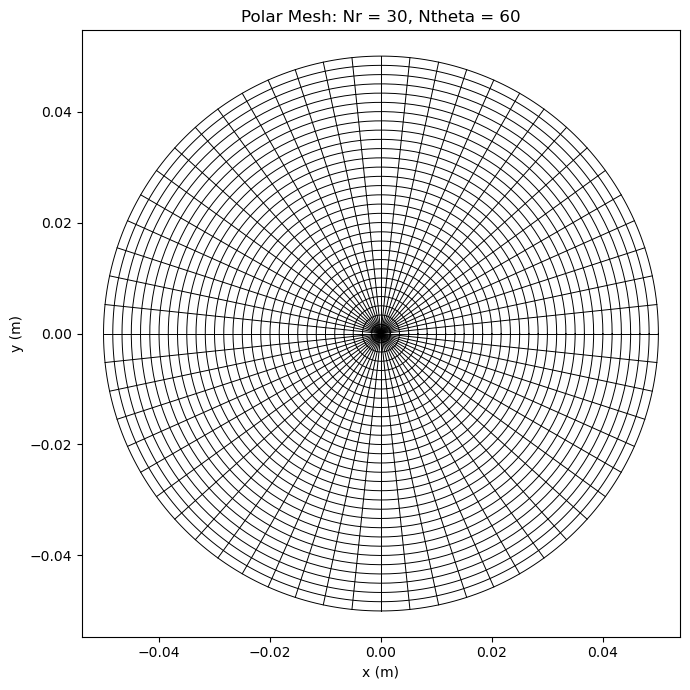

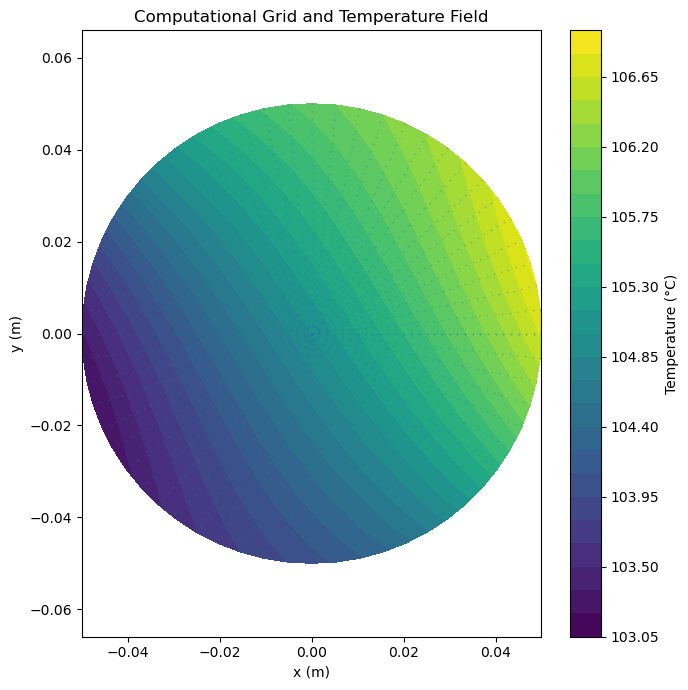

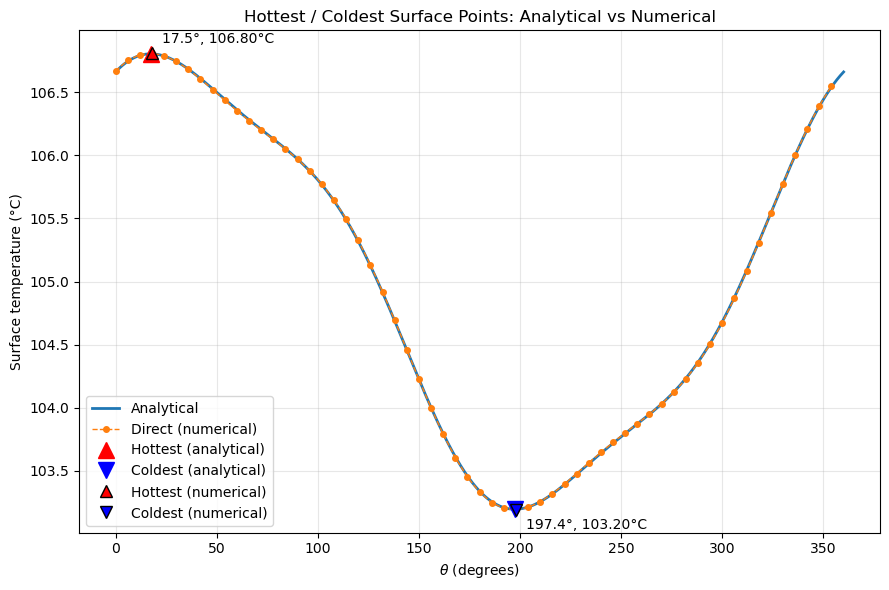

HOTTEST / COLDEST POINTS
  Analytical hottest: theta =   17.47 deg,  T = 106.8043 C
  Analytical coldest: theta =  197.38 deg,  T = 103.1957 C
  Numerical  hottest: theta =   18.00 deg,  T = 106.8095 C
  Numerical  coldest: theta =  198.00 deg,  T = 103.1905 C


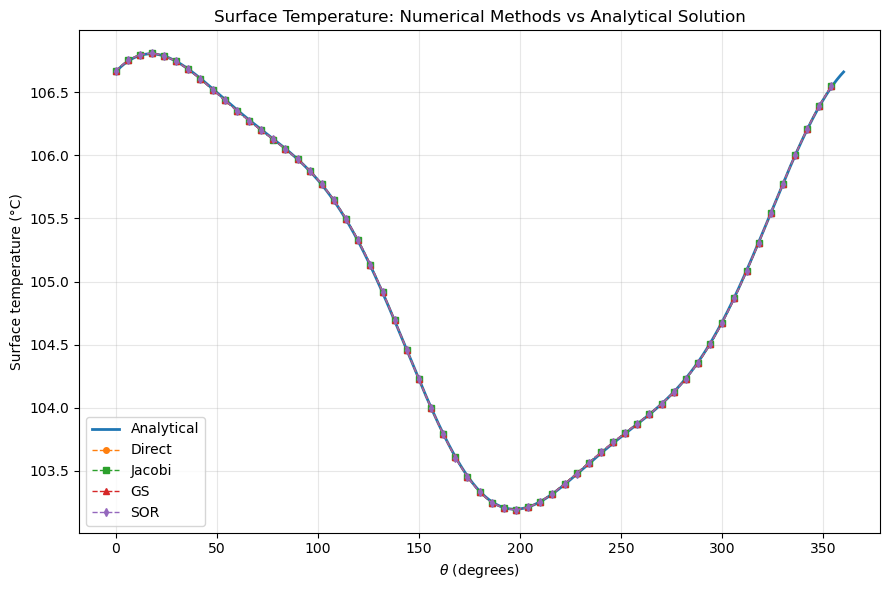

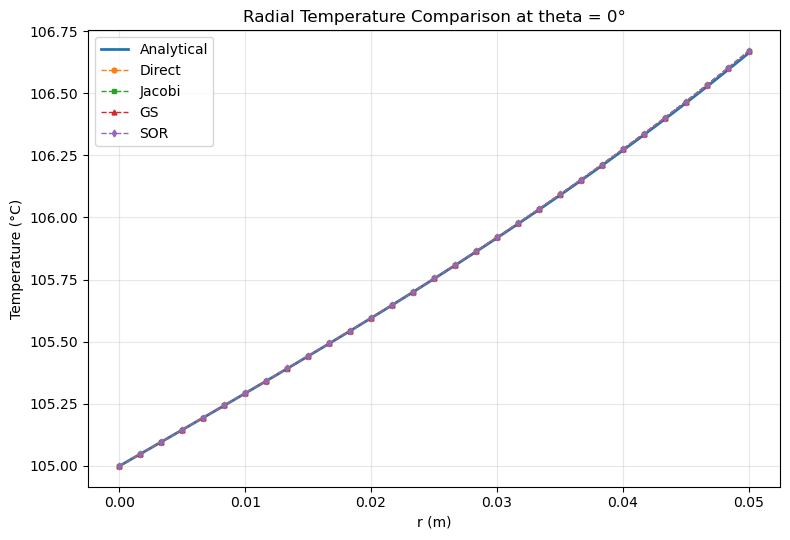

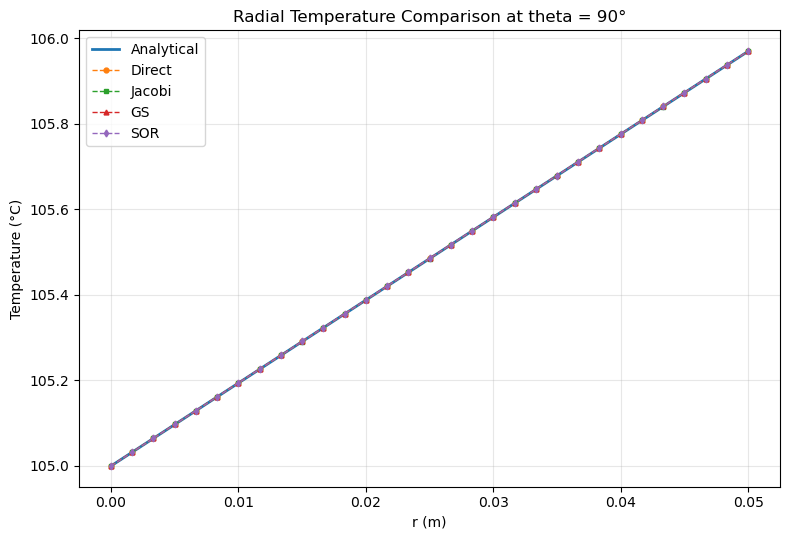

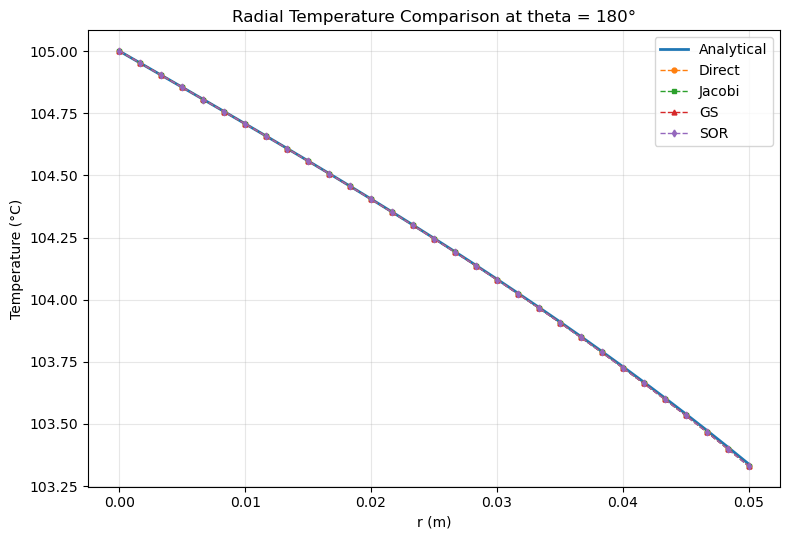

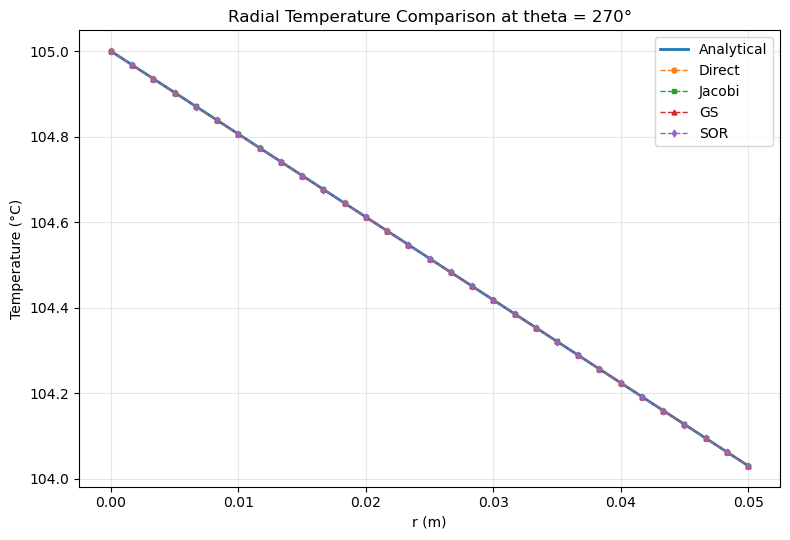

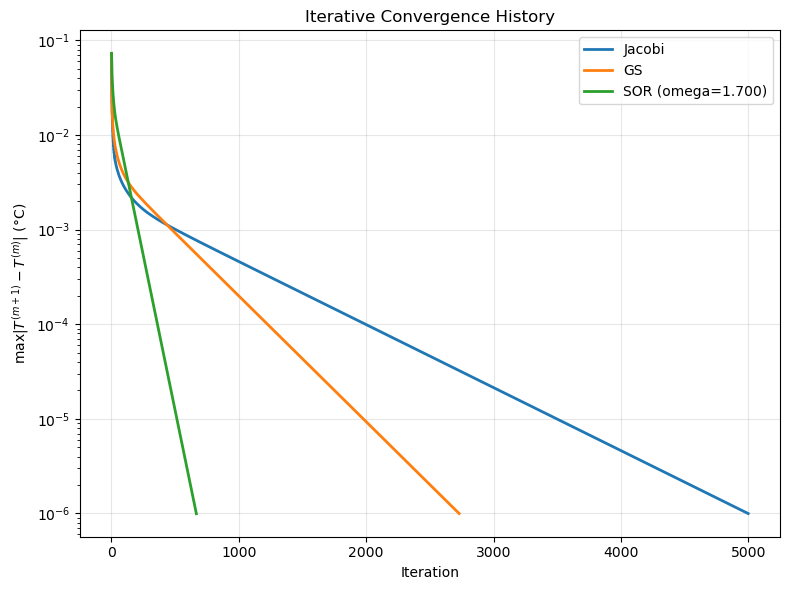

GRID REFINEMENT STUDY


,Grid,Nr,Ntheta,Unknowns,dr (m),Maximum absolute error (°C),Direct time (s)
0,Coarse,10,20,200,5.000000e-03,2.499e-01,0.000922
1,Medium,20,40,800,2.500000e-03,7.388e-03,0.002360
2,Fine,40,80,3200,1.250000e-03,2.922e-03,0.008405
3,Very Fine,80,120,9600,6.250000e-04,1.410e-03,0.036124


In [96]:
def extract_solution(T_flat, Nr, Ntheta):
   
# Convert the flat numerical solution into a polar field.
# Row 0 corresponds to r = 0 (the pole).
#Rows 1...Nr correspond to the actual numerical rings.
#The pole temperature is reconstructed from the first ring.


    field = np.zeros((Nr + 1, Ntheta))

    # Numerical solution:
    # flat index corresponds to i = 1...Nr
    field[1:, :] = T_flat.reshape((Nr, Ntheta))

    # At r = 0 the temperature is single-valued.
    # Use the average of the first ring.
    field[0, :] = np.mean(field[1, :])

    return field

fields = {
    "Direct": extract_solution(T_direct, Nr, Ntheta),
    "Jacobi": extract_solution(T_jac, Nr, Ntheta),
    "GS": extract_solution(T_gs, Nr, Ntheta),
    "SOR": extract_solution(T_sor, Nr, Ntheta)
}


results = {
    "A": A,
    "b": b,

    "direct": {
        "T": T_direct,
        "time": meta_direct["wall_s"],
        "iterations": 0,
        "res": []
    },

    "jacobi": {
        "T": T_jac,
        "time": meta_jac["wall_s"],
        "iterations": iter_jac,
        "res": res_jac
    },

    "gs": {
        "T": T_gs,
        "time": meta_gs["wall_s"],
        "iterations": iter_gs,
        "res": res_gs
    },

    "sor": {
        "T": T_sor,
        "time": meta_sor["wall_s"],
        "iterations": iter_sor,
        "res": res_sor,
        "omega": 1.7
    }
}

# 1. SELECTED NODAL TEMPERATURE TABLE

def nodal_temperature_table(fields):

    dr = R / Nr
    dtheta = 2*np.pi / Ntheta

    radii = [0.25*R, 0.50*R, 0.75*R]
    angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]

    rows = []

    for r_target in radii:

        i = int(round(r_target / dr))
        i = min(max(i, 0), Nr)

        r_actual = i * dr

        for theta_deg in angles_deg:

            theta = np.deg2rad(theta_deg)

            j = int(round(theta / dtheta)) % Ntheta

            T_ana = analytical_solution(r_actual, theta)

            rows.append([
                r_actual,
                r_actual / R,
                theta_deg,
                T_ana,
                fields["Direct"][i, j],
                fields["Jacobi"][i, j],
                fields["GS"][i, j],
                fields["SOR"][i, j]
            ])

    df = pd.DataFrame(
        rows,
        columns=[
            "r (m)",
            "r/R",
            "theta (deg)",
            "Analytical (°C)",
            "Direct (°C)",
            "Jacobi (°C)",
            "GS (°C)",
            "SOR (°C)"
        ]
    )
    
    print("SELECTED NODAL TEMPERATURES")

    display(
        df.style.format({
            "r (m)": "{:.5f}",
            "r/R": "{:.2f}",
            "theta (deg)": "{:.0f}",
            "Analytical (°C)": "{:.6f}",
            "Direct (°C)": "{:.6f}",
            "Jacobi (°C)": "{:.6f}",
            "GS (°C)": "{:.6f}",
            "SOR (°C)": "{:.6f}"
        })
    )

    return df

# 2. METHOD PERFORMANCE TABLE
def method_performance_table(results):

    T_direct = results["direct"]["T"]

    rows = []

    for name, key in [
        ("Direct LU", "direct"),
        ("Jacobi", "jacobi"),
        ("GS", "gs"),
        ("SOR", "sor")
    ]:

        item = results[key]
        T = item["T"]

        # Relative residual
        residual = (
            np.linalg.norm(results["A"] @ T - results["b"], ord=np.inf)
            / max(np.linalg.norm(results["b"], ord=np.inf), 1e-30)
        )

        diff_direct = np.max(np.abs(T - T_direct))

        if key == "direct":
            iterations = "-"
        else:
            iterations = item["iterations"]

        rows.append([
            name,
            iterations,
            item["time"],
            residual,
            diff_direct
        ])

    df = pd.DataFrame(
        rows,
        columns=[
            "Method",
            "Iterations",
            "Time (s)",
            "Relative residual",
            "Max |T - T_direct| (°C)"
        ]
    )

    print("METHOD PERFORMANCE COMPARISON")

    display(
        df.style.format({
            "Time (s)": "{:.6f}",
            "Relative residual": "{:.3e}",
            "Max |T - T_direct| (°C)": "{:.3e}"
        })
    )

    print(f"\nSOR relaxation factor: omega = {results['sor']['omega']:.3f}")

    return df
# ============================================================
# 3. SURFACE TEMPERATURE COMPARISON
# ============================================================

def plot_surface_comparison(fields):

    theta_fine = np.linspace(0, 2*np.pi, 1000)
    theta_num = np.arange(Ntheta) * (2*np.pi/Ntheta)

    plt.figure(figsize=(9, 6))

    plt.plot(
        np.rad2deg(theta_fine),
        analytical_surface(theta_fine),
        label="Analytical",
        linewidth=2
    )

    markers = {
        "Direct": "o",
        "Jacobi": "s",
        "GS": "^",
        "SOR": "d"
    }

    for name, marker in markers.items():

        plt.plot(
            np.rad2deg(theta_num),
            fields[name][Nr, :],
            marker=marker,
            linestyle="--",
            markersize=4,
            linewidth=1,
            label=name
        )

    plt.xlabel(r"$\theta$ (degrees)")
    plt.ylabel("Surface temperature (°C)")
    plt.title("Surface Temperature: Numerical Methods vs Analytical Solution")

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        "surface_temperature_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 4. RADIAL TEMPERATURE COMPARISON

def plot_radial_comparison(fields):

    theta_list = [0, 90, 180, 270]

    dr = R / Nr

    r_num = np.arange(Nr + 1) * dr
    r_R = r_num / R

    for theta_deg in theta_list:

        theta = np.deg2rad(theta_deg)

        j = int(round(theta / (2*np.pi/Ntheta))) % Ntheta

        # Analytical radial solution
        A0 = q0 / h
        A1 = q1 / (h + k/R)
        B1 = q2 / (h + k/R)
        A3 = q3 / (h + 3*k/R)

        T_ana = (
            T_inf
            + A0
            + r_R * (
                A1*np.cos(theta)
                + B1*np.sin(theta)
            )
            + r_R**3 * A3*np.cos(3*theta)
        )

        plt.figure(figsize=(8, 5.5))

        plt.plot(
            r_num,
            T_ana,
            label="Analytical",
            linewidth=2
        )

        for name, marker in [
            ("Direct", "o"),
            ("Jacobi", "s"),
            ("GS", "^"),
            ("SOR", "d")
        ]:

            plt.plot(
                r_num,
                fields[name][:, j],
                marker=marker,
                linestyle="--",
                markersize=3.5,
                linewidth=1,
                label=name
            )

        plt.xlabel("r (m)")
        plt.ylabel("Temperature (°C)")
        plt.title(
            f"Radial Temperature Comparison at "
            f"theta = {theta_deg}°"
        )

        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            f"radial_temperature_theta_{theta_deg}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

# 5. ITERATIVE CONVERGENCE HISTORY

def plot_iterative_convergence(results):

    plt.figure(figsize=(8, 6))

    plt.semilogy(
        np.arange(1, len(results["jacobi"]["res"]) + 1),
        results["jacobi"]["res"],
        label="Jacobi",
        linewidth=2
    )

    plt.semilogy(
        np.arange(1, len(results["gs"]["res"]) + 1),
        results["gs"]["res"],
        label="GS",
        linewidth=2
    )

    plt.semilogy(
        np.arange(1, len(results["sor"]["res"]) + 1),
        results["sor"]["res"],
        label=f"SOR (omega={results['sor']['omega']:.3f})",
        linewidth=2
    )

    plt.xlabel("Iteration")
    plt.ylabel(
        r"$\max|T^{(m+1)}-T^{(m)}|$ (°C)"
    )

    plt.title("Iterative Convergence History")

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        "iterative_convergence.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# 6. GRID REFINEMENT STUDY

def grid_refinement_report():

    grids = [
        (10, 20, "Coarse"),
        (20, 40, "Medium"),
        (40, 80, "Fine"),
        (80, 120, "Very Fine")
    ]

    radii = [0.25*R, 0.50*R, 0.75*R]
    angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]

    rows = []
    errors = []
    drs = []

    for Nr_g, Nt_g, label in grids:

        A_g, b_g, N_g, counts_g = build_system(Nr_g, Nt_g)

        start = time.perf_counter()

        T_g = solve_direct(A_g, b_g)

        elapsed = time.perf_counter() - start

        dr_g = R / Nr_g
        dtheta_g = 2*np.pi / Nt_g

        field_g = extract_solution(T_g, Nr_g, Nt_g)

        validation_errors = []

        for r_target in radii:

            i = int(round(r_target / dr_g))
            i = min(max(i, 0), Nr_g)

            r_actual = i * dr_g

            for theta_deg in angles_deg:

                theta = np.deg2rad(theta_deg)

                j = int(round(theta / dtheta_g)) % Nt_g

                T_ana = analytical_solution(
                    r_actual,
                    theta
                )

                T_num = field_g[i, j]

                validation_errors.append(
                    abs(T_num - T_ana)
                )

        max_err = max(validation_errors)

        rows.append([
            label,
            Nr_g,
            Nt_g,
            N_g,
            dr_g,
            max_err,
            elapsed
        ])

        errors.append(max_err)
        drs.append(dr_g)

    df = pd.DataFrame(
        rows,
        columns=[
            "Grid",
            "Nr",
            "Ntheta",
            "Unknowns",
            "dr (m)",
            "Maximum absolute error (°C)",
            "Direct time (s)"
        ]
    )

    print("GRID REFINEMENT STUDY")

    display(
        df.style.format({
            "dr (m)": "{:.6e}",
            "Maximum absolute error (°C)": "{:.3e}",
            "Direct time (s)": "{:.6f}"
        })
    )


# 7. POLAR MESH

def plot_mesh(Nr, Ntheta, R):

    dr = R / Nr
    dtheta = 2*np.pi / Ntheta

    plt.figure(figsize=(7, 7))

    # Radial lines
    r = np.linspace(0, R, Nr + 1)

    for j in range(Ntheta):

        theta = j * dtheta

        x = r * np.cos(theta)
        y = r * np.sin(theta)

        plt.plot(x, y, 'k', linewidth=0.7)

    # Circular lines
    theta_circle = np.linspace(0, 2*np.pi, 300)

    for i in range(1, Nr + 1):

        x = i * dr * np.cos(theta_circle)
        y = i * dr * np.sin(theta_circle)

        plt.plot(x, y, 'k', linewidth=0.7)

    plt.axis("equal")

    plt.xlabel("x (m)")
    plt.ylabel("y (m)")

    plt.title(
        f"Polar Mesh: Nr = {Nr}, Ntheta = {Ntheta}"
    )

    plt.grid(False)
    plt.tight_layout()

    plt.savefig(
        "polar_mesh.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# 8. TEMPERATURE FIELD

def plot_grid_and_temperature(fields):

    T = fields["Direct"]

    dr = R / Nr
    dtheta = 2*np.pi / Ntheta

    r = np.arange(Nr + 1) * dr
    theta = np.arange(Ntheta) * dtheta

    # Add theta = 2*pi for plotting only
    theta_plot = np.append(theta, 2*np.pi)

    # Repeat theta = 0 temperature at theta = 2*pi
    T_plot = np.column_stack((T, T[:, 0]))

    Rg, Tg = np.meshgrid(
        r,
        theta_plot,
        indexing="ij"
    )

    X = Rg * np.cos(Tg)
    Y = Rg * np.sin(Tg)

    plt.figure(figsize=(7, 7))

    plt.contourf(
        X,
        Y,
        T_plot,
        levels=30,
        cmap = 'viridis'
    )

    plt.colorbar(
        label="Temperature (°C)"
    )

    plt.plot(
        X.ravel(),
        Y.ravel(),
        ".",
        markersize=1,
        alpha=0.25
    )

    plt.xlabel("x (m)")
    plt.ylabel("y (m)")

    plt.title(
        "Computational Grid and Temperature Field"
    )

    plt.axis("equal")
    plt.tight_layout()

    plt.savefig(
        "grid_temperature_field.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 9. HOTTEST / COLDEST POINTS

def plot_hot_cold_points(fields):

    theta_fine = np.linspace(0, 2*np.pi, 2000)
    T_ana_fine = analytical_surface(theta_fine)

    i_hot_ana = np.argmax(T_ana_fine)
    i_cold_ana = np.argmin(T_ana_fine)

    theta_hot_ana = theta_fine[i_hot_ana]
    theta_cold_ana = theta_fine[i_cold_ana]

    theta_num = np.arange(Ntheta) * (2*np.pi/Ntheta)
    T_surface_num = fields["Direct"][Nr, :]

    i_hot_num = np.argmax(T_surface_num)
    i_cold_num = np.argmin(T_surface_num)

    theta_hot_num = theta_num[i_hot_num]
    theta_cold_num = theta_num[i_cold_num]

    plt.figure(figsize=(9, 6))

    plt.plot(np.rad2deg(theta_fine), T_ana_fine, label="Analytical", linewidth=2)
    plt.plot(np.rad2deg(theta_num), T_surface_num, "o--", markersize=4,
             linewidth=1, label="Direct (numerical)")

    plt.plot(np.rad2deg(theta_hot_ana), T_ana_fine[i_hot_ana], "r^",
             markersize=12, label="Hottest (analytical)")
    plt.plot(np.rad2deg(theta_cold_ana), T_ana_fine[i_cold_ana], "bv",
             markersize=12, label="Coldest (analytical)")
    plt.plot(np.rad2deg(theta_hot_num), T_surface_num[i_hot_num], "r^",
             markersize=9, markeredgecolor="k", label="Hottest (numerical)")
    plt.plot(np.rad2deg(theta_cold_num), T_surface_num[i_cold_num], "bv",
             markersize=9, markeredgecolor="k", label="Coldest (numerical)")

    plt.annotate(f"{np.rad2deg(theta_hot_ana):.1f}°, {T_ana_fine[i_hot_ana]:.2f}°C",
                 (np.rad2deg(theta_hot_ana), T_ana_fine[i_hot_ana]),
                 textcoords="offset points", xytext=(8, 8))
    plt.annotate(f"{np.rad2deg(theta_cold_ana):.1f}°, {T_ana_fine[i_cold_ana]:.2f}°C",
                 (np.rad2deg(theta_cold_ana), T_ana_fine[i_cold_ana]),
                 textcoords="offset points", xytext=(8, -14))

    plt.xlabel(r"$\theta$ (degrees)")
    plt.ylabel("Surface temperature (°C)")
    plt.title("Hottest / Coldest Surface Points: Analytical vs Numerical")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("hot_cold_points.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("HOTTEST / COLDEST POINTS")
    print(f"  Analytical hottest: theta = {np.rad2deg(theta_hot_ana):7.2f} deg,  T = {T_ana_fine[i_hot_ana]:.4f} C")
    print(f"  Analytical coldest: theta = {np.rad2deg(theta_cold_ana):7.2f} deg,  T = {T_ana_fine[i_cold_ana]:.4f} C")
    print(f"  Numerical  hottest: theta = {np.rad2deg(theta_hot_num):7.2f} deg,  T = {T_surface_num[i_hot_num]:.4f} C")
    print(f"  Numerical  coldest: theta = {np.rad2deg(theta_cold_num):7.2f} deg,  T = {T_surface_num[i_cold_num]:.4f} C")

    return {
        "theta_hot_ana": theta_hot_ana, "T_hot_ana": T_ana_fine[i_hot_ana],
        "theta_cold_ana": theta_cold_ana, "T_cold_ana": T_ana_fine[i_cold_ana],
        "theta_hot_num": theta_hot_num, "T_hot_num": T_surface_num[i_hot_num],
        "theta_cold_num": theta_cold_num, "T_cold_num": T_surface_num[i_cold_num],
    }
# MAIN REPORT

if __name__ == "__main__":


    nodal_df = nodal_temperature_table(fields)

    performance_df = method_performance_table(results)

    plot_mesh(Nr, Ntheta, R)

    plot_grid_and_temperature(fields)
    
    plot_hot_cold_points(fields)

    plot_surface_comparison(fields)

    plot_radial_comparison(fields)

    plot_iterative_convergence(results)

    grid_df = grid_refinement_report()


**8.2** Solver comparison — convergence history, &omega; sweep, and wall-clock time by method.

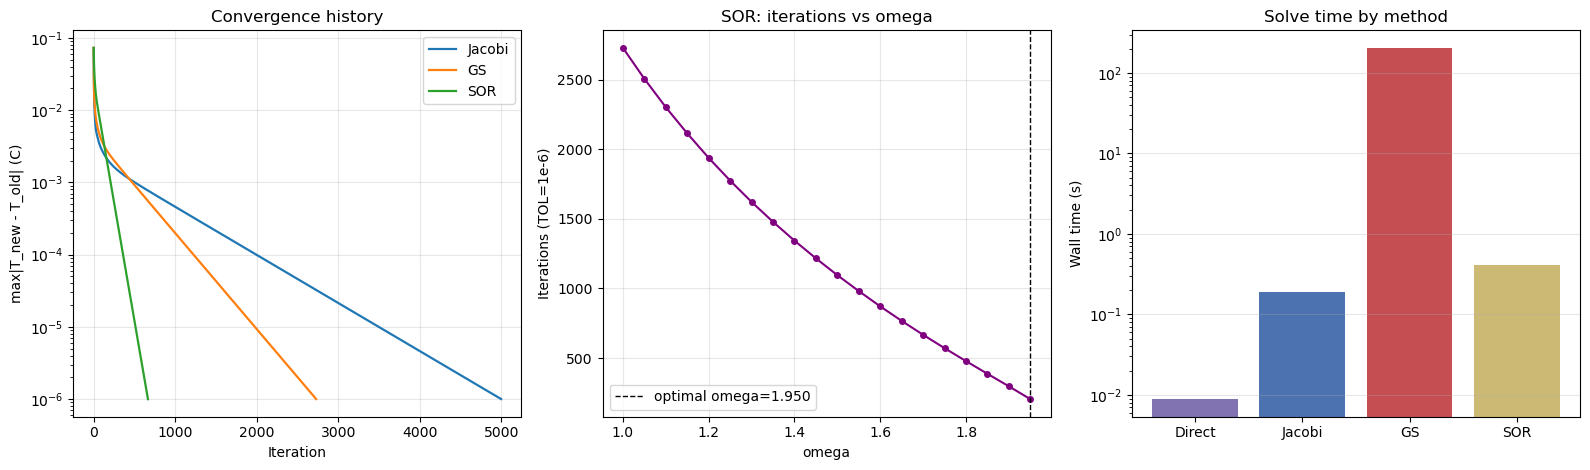

In [50]:
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8))

# ------------------------------------------------------------
# Convergence history
# ------------------------------------------------------------
for name, res in [('Jacobi', res_jac),
                  ('GS', res_gs),
                  ('SOR', res_sor)]:
    axes2[0].semilogy(res, label=name, linewidth=1.6)

axes2[0].set_xlabel('Iteration')
axes2[0].set_ylabel('max|T_new - T_old| (C)')
axes2[0].set_title('Convergence history')
axes2[0].grid(alpha=0.3)
axes2[0].legend()


# ------------------------------------------------------------
# SOR: iterations vs omega
# ------------------------------------------------------------
axes2[1].plot(omegas, iters_sweep, 'o-', color='purple', markersize=4)
axes2[1].axvline(omega_opt, color='k', linestyle='--',
                 linewidth=1,
                 label=f'optimal omega={omega_opt:.3f}')

axes2[1].set_xlabel('omega')
axes2[1].set_ylabel('Iterations (TOL=1e-6)')
axes2[1].set_title('SOR: iterations vs omega')
axes2[1].grid(alpha=0.3)
axes2[1].legend()


# ------------------------------------------------------------
# Solve time by method
# ------------------------------------------------------------
methods = ['Direct', 'Jacobi', 'GS', 'SOR']

times = [meta_direct['wall_s'],
         meta_jac['wall_s'],
         meta_gs['wall_s'],
         meta_sor['wall_s']]

axes2[2].bar(methods, times,
             color=['#8172B2', '#4C72B0', '#C44E52', '#CCB974'])

axes2[2].set_yscale('log')
axes2[2].set_ylabel('Wall time (s)')
axes2[2].set_title('Solve time by method')
axes2[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

  <div style="page-break-before: always;"></div>

## Discussion on the results 
<div style="text-align: justify;">
    <ul>
        <li><strong>Direct (Sparse LU)</strong> is exact (to round-off) and by far the fastest for this problem size (0.013 s) — the reference solution used everywhere above.</li>
        <br>
        <li><strong>Jacobi</strong> needs the most iterations of any method (4999, using only last-iteration values),
            but since it's implemented as a sparse matrix-vector product each sweep,  
            it still finishes in 0.15 s iteration count alone doesn't tell you wall-clock cost.</li>
        <br>
        <li><strong>Gauss-Seidel vs. SOR's vectorized core</strong>: setting <code>omega=1.0</code> in the SOR cell (6.4) solves the <em>same</em> equations as the  
            loop-based Gauss-Seidel in 6.3 — both converge to within &lt;1e-3 °C of Direct. The two implementations differ only in wall-clock time: <strong>176.6 s  
                for the row-by-row Python loop (2730 iterations) vs. 0.36 s for the vectorized red-black sweep at ω=1.7 (667 iterations)</strong> — roughly a 490× speedup for solving the same linear system.</li>
        <br>
        <li><strong>SOR</strong> with a well-chosen ω (optimal ≈ 1.95) converges in far fewer iterations than plain Gauss-Seidel (667 vs. 2730 at ω=1.7, dropping to 205 at the optimum) — over-relaxation is buying real algorithmic speedup here, not just implementation speedup.</li>
        <br>
        <li><strong>Grid refinement</strong>: max error at the validation points drops from 0.250 °C (coarse, Nr=10) to 0.0014 °C (very fine, Nr=80) as the grid is refined, consistent with the finite-difference discretization converging toward the analytical solution. Direct-solve time grows from 0.5 ms to 76 ms over that same range — still trivial for the direct solver at these sizes, but the range where the loop-based Gauss-Seidel would start to hurt in comparison.</li>
        <br>
        <li><strong>Increase</strong> <code>Nr</code>/<code>Ntheta</code> in Section 3 to push accuracy up further: the direct solver and the vectorized iterative methods (Jacobi, SOR) will stay fast, while the original row-loop Gauss-Seidel cell (6.3) will get noticeably slower.</li>
    </ul>
</div>

  <div style="page-break-before: always;"></div>
  

# APPENDIX
## CLick the link below to find the source code:

https://github.com/TarekIssa-98/CFD/blob/main/Assignment-1-problem5_code.py

### Note that, With Nr = 30 and N_theta = 60Python's will take up to 3~4 miutes to give the output as Gauss-Seidel method require higher iteration and solve line by line, for faster results, you can reduce Nr and N_theta values (e.g 10, 32).